# NB1 : Building Schema & Preliminary Feature Engineering


In [173]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
import seaborn as sns
import os

# Project Introduction

To assist early career researchers in establishing their prestige, we demonstrate how machine learning can help early career researchers identify potential co-authors within their network whose added authorship could increase the likelihood of their research being published in highly-cited scientific journals. Specifically, we show that a classification model trained on a database of publications authored by prestigious researchers can successfully classify publications into tiers of highly-cited scientific journals using co-author metrics alone. 

## Notebook Introduction

In this notebook, we perform preliminary data cleaning on the raw data sets pulled from Google Scholar using the [Publish or Perish]( https://harzing.com/resources/publish-or-perish) web scraping software and publication metric hosting online data base [Scimago Journal & Country Rank](https://www.scimagojr.com/journalrank.php). 

Our goal is to create a relational database of data tables that contain minimal null entries, duplicated rows and uniform formatting of features. To start, the database will include three tables:

1. `profile_df`: The meta data for each of the sampled Google Scholar profiles.
 
2. `papers_df`: All the citation entries for each of the first 1000 papers pulled from the sampled Google Scholar profiles.

3. `jour_df`: Contains metrics about publications sources divided into different subject areas. 

# Section 1: Data Cleaning & Building Relational Data Tables

## 1.1 Creating Keys To Join `profile_df` and `papers_df`

The goal of **Section 1.1** is to join each citation entry in `papers_df` with its corresponding profile author in `profile_df`. We perform this join by assigning foreign keys to entries in `papers_df` and primary keys to `profile_df`. Currently, the entries in `papers_df` do not have any columns that indicate which Google Scholar profile they were scrapped from. Therefore, to assign the foreign keys to `papers_df`, we demonstrate a method that identifies patterns in the `Cites` features that correspond to changes in the profile author assignment. 

### 1.1.1 Inspecting the Data Sets

First, let's inspect `profile_df`

In [58]:
profile_df = pd.read_csv(r"RawData\PublishOrPerish\author_PoPMetrics_V2.2.csv")

In [59]:
profile_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 616 entries, 0 to 615
Data columns (total 34 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Query              616 non-null    object 
 1   Source             616 non-null    object 
 2   Papers             616 non-null    int64  
 3   Citations          616 non-null    int64  
 4   Years              616 non-null    int64  
 5   Cites_Year         616 non-null    float64
 6   Cites_Paper        616 non-null    float64
 7   Cites_Author       616 non-null    float64
 8   Papers_Author      616 non-null    float64
 9   Authors_Paper      616 non-null    float64
 10  h_index            616 non-null    int64  
 11  g_index            616 non-null    int64  
 12  hc_index           616 non-null    int64  
 13  hI_index           616 non-null    float64
 14  hI_norm            616 non-null    int64  
 15  AWCR               616 non-null    float64
 16  AW_index           616 non

`profile_df` has 616 entries and 34 columns with no null values. 
Let's investigate `papers_df`

In [60]:
papers_df = pd.read_csv(r"RawData\PublishOrPerish\results_PoPCites_V2.2.csv",low_memory = True)

In [61]:
papers_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33531 entries, 0 to 33530
Data columns (total 26 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Cites           33531 non-null  int64  
 1   Authors         33511 non-null  object 
 2   Title           33531 non-null  object 
 3   Year            32272 non-null  float64
 4   Source          31433 non-null  object 
 5   Publisher       218 non-null    object 
 6   ArticleURL      0 non-null      float64
 7   CitesURL        33531 non-null  object 
 8   GSRank          33531 non-null  int64  
 9   QueryDate       33531 non-null  object 
 10  Type            29640 non-null  object 
 11  DOI             0 non-null      float64
 12  ISSN            0 non-null      float64
 13  CitationURL     33531 non-null  object 
 14  Volume          25912 non-null  float64
 15  Issue           19123 non-null  float64
 16  StartPage       25035 non-null  float64
 17  EndPage         24814 non-null 

`papers_df` has 33,531 entries and 26 columns. 

In reguards to `profile_df`, we are only interested in the column `Query` that holds the name and institutions of the researcher. While the other columns in `profile_df` could give us exciting metrics about the researcher for our model to train on, because it is unlikely that most of the cited authors in the over 30,000 citation entries in `paper_df` would be accounted for in the 616 entires in `profile_df`, including the additional metrics from `profile_df` would lead to an imbalance of features for each author. Therefore, let’s modify `profile_df` only to contain the `Query` column.

*Note on duplicated entries in `profile_df`*

Because the web scrapping software appended the entries in `papers_df` and `profile_id` in the same order, if the software scrapped any profiles more than once, their entries would be appended to `papers_df` more than once. However, identifying which entries in `papers_df` were duplicated because the software scrapped their corresponding Google Scholar profile more than once from entries duplicated for other reasons will first require assigning the foreign key to the entries in `papers_df`. Below, we demonstrate how to use this appending order in `papers_df` and `profile_df` to assign foreign keys to the entries in `papers_df`. Therefore, while `profile_df` may contain duplicate entries, removing these entries before assigning foreign keys to `papers_df` will prevent all the entries in `papers_df` from being properly assigned foreign keys.

In [62]:
profile_df = profile_df.loc[:, 'Query']

In [63]:
profile_df.info()

<class 'pandas.core.series.Series'>
RangeIndex: 616 entries, 0 to 615
Series name: Query
Non-Null Count  Dtype 
--------------  ----- 
616 non-null    object
dtypes: object(1)
memory usage: 4.9+ KB


### 1.1.2 Create Primary Keys in `profile_df`

The first step to being able to join `papers_df` with `profile_df` is to assign a primary key to each of the entries in `profile_df`. We can do this by assigning the indexing column as the primary key `id`. 

In [64]:
# Resetting the index to insert the index into dataframe columns.
profile_df = profile_df.reset_index()

# Renaming the columns
profile_df.columns = ['id', 'Query']

In [65]:
# Setting data type of `id` to int16
profile_df['id'] = profile_df['id'].astype('int16')

profile_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 616 entries, 0 to 615
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      616 non-null    int16 
 1   Query   616 non-null    object
dtypes: int16(1), object(1)
memory usage: 6.1+ KB


### 1.1.3 Creating Foreign Keys in `papers_df`

We will create a new column in `papers_id` called `profile_id` which will hold a foreign key to link the entries in the `papers_df` with their respective Google scholar profiles in `profile_df`. This will be used to join `papers_df` and `profile_df`. Since the web scraper exported the entries in `papers_df` in descending order by `Citations`, we will identify which entry in `papers_df` correspond to which Google scholar profiles in `profile_df` by finding where the values in `Citations` reset to a values than is greater than the previous entry in `Citations`.

*Example*: Below is an example entries of `papers_df` demonstrating that at index 5, the `profile_id` value switches to a different key since the value in the `Citations` column (10) reset to a values than is greater than the previous entry in `Citations` at index 4 (0).



| Index | Citations | profile_id |
--- | --- | ---|
|0|5|0|
|1|3|0|
|2|2|0|
|3|0|0|
|4|0|0|
|5|10|1|
|6|7|1|

In [66]:
cites = papers_df.loc[:, 'Cites'].values

# Get the number of rows in the papers_df
rows, cols = papers_df.shape

# Get indexs for start and stop
start_list = [0]
end_list = []

# findings starting and endings points for each profile_id entry
for i in range(rows):
    j = i + 1
    if j >= rows:
        break
    else:
        if cites[j]-cites[i] > 0:
            end_list.append(i)
            start_list.append(j)

end_list.append(rows)

au_rows, au_cols = profile_df.shape

# Assign profile_ids
profile_id = np.zeros(rows)
for i in range(au_rows):
    start, stop = start_list[i], end_list[i]+1
    profile_id[start:stop] = i

# Save profile series to df
quer_ser = pd.Series(profile_id)
papers_df['profile_id'] = quer_ser

We see that the `papers_df` has a new column `profile_id`

In [67]:
papers_df['profile_id'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 33531 entries, 0 to 33530
Series name: profile_id
Non-Null Count  Dtype  
--------------  -----  
33531 non-null  float64
dtypes: float64(1)
memory usage: 262.1 KB


We can check if all the entires in the `profile_df` are accounted for in the `profile_id` column by checking if the unique values in the `profile_id` column equals the number of entries in the `profile_df`.

In [68]:
papers_df['profile_id'].value_counts().count() == profile_df.shape[0]

True

The number of entries match, suggesting that generating the value for the `profile_id` column was successful! Let's confirm further that all the entries in `paper_df` are able to join to a entry in `profile_id` by performing a left join on `profile_id`.

In [69]:
join_df = pd.merge(left = papers_df, right = profile_df, left_on = 'profile_id', right_on = 'id', how = 'left')

# Counting the null values in the `id` column to determine how many entries in `papers_df` were not able to join 
num = join_df['id'].isna().sum()
print(f'{num} entries in papers_df did NOT have a corresponding id in profile_df')

0 entries in papers_df did NOT have a corresponding id in profile_df


All the entries in `papers_df` were able to join to an entry in `profile_id`! We now have a foreign key to join the entires in `papers_df` to `profile_df`. This will be helpful when needing to access information only available in the from the `profile_df` for each entry.

---

## 1.2 Building `jour_df` 

The goal of **Section 1.2** is to concatenate the individual data set pulled from [Scimago Journal & Country Rank](https://www.scimagojr.com/journalrank.php) into a single data frame called `jour_df` and clean that data frame such that we can *join* the titles of the publications onto the publication titles in the `papers_df` so that `papers_df` will contain metric information about the source that will influence the entry's rank.

Given the scope of researchers who have published work in perovskites, we have pulled publications from the following subject areas:
- Materials Science
- Environmental Science
- Engineering
- Energy
- Chemistry
- Physics and Astronomy
- Chemical Engineering
- Multidisciplinary (contains journals of interest such as Nature and Science)

### 1.2.1 Concatenate the Data Sets

To ensure the successful conversion of the original data from the CSV file into a Pandas data frame, we must first perform preliminary text format editing. We accomplish this by iterating through the lines in the CSV file and using the `.replace()` method to modify any strings that require reformatting. We then append each line, whether edited or not, to a `txt` file that will be utilized in generating the Pandas data frame. Our specific modification involves replacing instances of `&amp;` with `&amp;`, as the delimiter is `;` and we want to avoid the columns splitting the string after `&amp;`.

*Note*: Attempts were made to edit the CSV files directly, but this ended up being the most effective method.

In [174]:
folder_path = r'G:\My Drive\BrainStation\BrainStationCapstone\Scripts and Notebooks\Raw Data\2023-03-03 Journal IF Datasets'
folder_out = r'G:\My Drive\BrainStation\BrainStationCapstone\Scripts and Notebooks\Raw Data\2023-03-03 Journal IF Datasets\output'
folder = os.listdir(folder_path)[:-1]

print('Here are the CSV Files being Edited:')
for file in folder:
    path = os.path.join(folder_path, file)
    print(file)
    out_path = os.path.join(folder_out, file).replace('.csv', '')
    with open(path, 'r') as f:
        with open(out_path + '_out.txt', 'a') as g:
            for idx, line in enumerate(f):
                    # need to replace '&amp' with &
                    new_line = line.replace('&amp;', '&')
                    g.write(new_line)

FileNotFoundError: [WinError 3] The system cannot find the path specified: 'G:\\My Drive\\BrainStation\\BrainStationCapstone\\Scripts and Notebooks\\Raw Data\\2023-03-03 Journal IF Datasets'

Next, we will concatenate the individual data frames stored in the `txt` files into one data frame titled `jour_df`.

In [176]:
folder = os.listdir(folder_out)

jour_df = pd.DataFrame()

print('Here are the TXT Files being Edited:')
for file in folder:
    path = os.path.join(folder_out, file)
    print(file)
    temp_file = np.genfromtxt(path, delimiter=';', usecols = (2,3,5,7,15,16), dtype = '<U500')
    temp_df = pd.DataFrame(temp_file[1:], columns = temp_file[0,:])
    jour_df = pd.concat([jour_df, temp_df], axis = 0)

FileNotFoundError: [WinError 3] The system cannot find the path specified: 'G:\\My Drive\\BrainStation\\BrainStationCapstone\\Scripts and Notebooks\\Raw Data\\2023-03-03 Journal IF Datasets\\output'

Here is the resulting data frame `jour_df`

## 1.2 Addressing Null Values and Duplicated Entries in `papers_df`

The objective of **Section 1.2** is to reduce the occurrence of null values and duplicated entries in papers_df to simplify the process of future feature engineering and model implementation. Because our ultimate aim is to classify entries into various tiers of highly-cited scientific journals solely based on co-author metrics, while removing null values and duplicated entries, we will prioritize retaining features in `papers_df` that have the potential to describe the author's publication prestige or the publication prestige of the citation entry itself.

First, let's investigate if there any duplicated entries in `papers_df`.

In [70]:
papers_df.duplicated().sum()

0

There are no duplicate entries in `papers_df`. Let's move on to investigating the null values.

Let's access the percentage of null values in `papers_df`for each column

In [71]:
(papers_df.isna().sum()/papers_df.isna().count()).sort_values(ascending = False)*100

RelatedURL        100.000000
ArticleURL        100.000000
FullTextURL       100.000000
Abstract          100.000000
DOI               100.000000
ISSN              100.000000
Publisher          99.349855
Issue              42.969193
EndPage            25.996839
StartPage          25.337747
Volume             22.722257
Type               11.604187
Source              6.256897
Age                 3.754734
Year                3.754734
Authors             0.059646
Cites               0.000000
CitesPerAuthor      0.000000
AuthorCount         0.000000
CitationURL         0.000000
CitesPerYear        0.000000
ECC                 0.000000
QueryDate           0.000000
GSRank              0.000000
CitesURL            0.000000
Title               0.000000
profile_id          0.000000
dtype: float64

Since the entries in the features where over 99% of the entries are null values are so sparse, let’s drop those columns entirely. 

In [72]:
papers_df = papers_df.drop(['Abstract', 'ArticleURL', 'DOI', 'FullTextURL', 'ISSN', 'RelatedURL', 'Publisher'], axis = 1)

In [73]:
(papers_df.isna().sum()/papers_df.isna().count()).sort_values(ascending = False)*100

Issue             42.969193
EndPage           25.996839
StartPage         25.337747
Volume            22.722257
Type              11.604187
Source             6.256897
Age                3.754734
Year               3.754734
Authors            0.059646
AuthorCount        0.000000
CitesPerAuthor     0.000000
CitesPerYear       0.000000
ECC                0.000000
Cites              0.000000
CitationURL        0.000000
QueryDate          0.000000
GSRank             0.000000
CitesURL           0.000000
Title              0.000000
profile_id         0.000000
dtype: float64

Since publications are typically added to journals in the order of acceptance, the `Volume`, `StartPage`, `EndPage` and `Issue` of each entry are unlikely to offer any valuable information about the publication's prestige. Furthermore, these columns have null values in over 20% of their entries. As a result, we should remove these columns from the dataset. Additionally, since `Age` and `Year` both contain information about when the citation was published (as evident by the identical percentage of null values in each feature) we can drop one of them. Let's drop `Age` and keep `Year`.

In [74]:
papers_df = papers_df.drop(['Age', 'Volume', 'StartPage', 'EndPage', 'Issue'], axis = 1)

Let's look at the remaining null values.

In [75]:
(papers_df.isna().sum()/papers_df.isna().count()).sort_values(ascending = False)*100

Type              11.604187
Source             6.256897
Year               3.754734
Authors            0.059646
Cites              0.000000
Title              0.000000
CitesURL           0.000000
GSRank             0.000000
QueryDate          0.000000
CitationURL        0.000000
ECC                0.000000
CitesPerYear       0.000000
CitesPerAuthor     0.000000
AuthorCount        0.000000
profile_id         0.000000
dtype: float64

Let's investigate the null values for the `Type` column. Let's start by looking at the value counts for each of the `Type` categories.

Text(0.5, 1.0, 'Distribution of Entry Types')

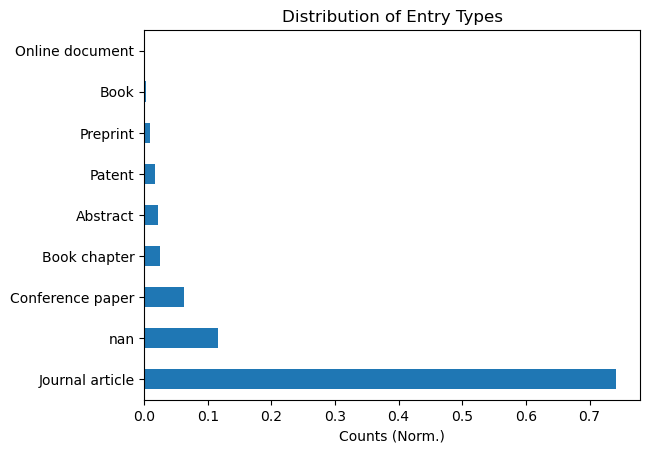

In [79]:
papers_df['Type'].value_counts(normalize = True, dropna = False).plot(kind = 'barh')
plt.xlabel('Counts (Norm.)')
plt.title('Distribution of Entry Types')

Based on the distribution of the `Type` column, it appears that null values account for slightly over 10% of the entries, while over 70% of the entries are classified as `Journal Article`. One method of removing the null entries in the `Type` column is to isolate the data set to only have the entries categorized as `Journal Article`. By focusing solely on the entries in the `Journal Article` class, we not only eliminate any existing null values but also potentially address any class imbalances within the remaining categories. This approach may improve the accuracy of the model at classifying citations into their publication tier, as it specifically trains the model to recognize features that are most predictive to classify citations of journals and not other publication types.

In [80]:
idx = papers_df[papers_df['Type'] != 'Journal article'].index
papers_df = papers_df.drop(idx).reset_index(drop = 'True')

Let's look at the remaining null values.

In [81]:
(papers_df.isna().sum()/papers_df.isna().count()).sort_values(ascending = False)*100

Year              0.048214
Authors           0.036161
Source            0.004018
Cites             0.000000
Title             0.000000
CitesURL          0.000000
GSRank            0.000000
QueryDate         0.000000
Type              0.000000
CitationURL       0.000000
ECC               0.000000
CitesPerYear      0.000000
CitesPerAuthor    0.000000
AuthorCount       0.000000
profile_id        0.000000
dtype: float64

Since the remaining null entries *combined* represent < 0.1% of the total entries in `papers_df`. Let's drop the entries containing any null values.

In [87]:
rows_before, cols_before = papers_df.shape

In [88]:
papers_df = papers_df.dropna().reset_index(drop = True)

In [89]:
rows_after, cols_after = papers_df.shape

In [95]:
per_before = rows_after/rows_before
print('After dropping the entries containing any null values, papers_df still maintains {:0.3%} of its original entries'.format(per_before))
print(f"That's {rows_after} entries")

After dropping the entries containing any null values, papers_df still maintains 99.912% of its original entries
That's 24867 entries


We still have over 20,000 entries which is a healthy amount.

Let's look at the distribution of remaining null values.

In [26]:
(papers_df.isna().sum()/papers_df.isna().count()).sort_values(ascending = False)

Year              0.000482
Source            0.000040
Cites             0.000000
Authors           0.000000
Title             0.000000
Type              0.000000
CitesPerYear      0.000000
CitesPerAuthor    0.000000
AuthorCount       0.000000
query_id          0.000000
dtype: float64

Let's check the null value distribution.

In [96]:
(papers_df.isna().sum()/papers_df.isna().count()).sort_values(ascending = False)*100

Cites             0.0
Authors           0.0
Title             0.0
Year              0.0
Source            0.0
CitesURL          0.0
GSRank            0.0
QueryDate         0.0
Type              0.0
CitationURL       0.0
ECC               0.0
CitesPerYear      0.0
CitesPerAuthor    0.0
AuthorCount       0.0
profile_id        0.0
dtype: float64

Hurray! There are zero remaining null values for `papers_df`. To conclude, we successfully removed all the null values in the `papers_df` to create a data frame of citation entries. We found the most effective method of removing null values was to isolate the data set only to include entries with `Types` values `Journal article` and removing columns that had over 99% of the entries as null and removing columns that described indexing information for the citation such as `Volume`, `StartPage`, `EndPage` and `Issue`. 

## 1.3: Optimizing `papers_df` for Memory Efficiency 

The goal of **Part 3** is to modify the entries and features of `papers_df` so that the data frame uses the least amount of memory possible. This is assist with loading and modifying the data frame in the future.

Let's start by look examining data types assigned to the columns in `papers_df`.

In [97]:
papers_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24867 entries, 0 to 24866
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Cites           24867 non-null  int64  
 1   Authors         24867 non-null  object 
 2   Title           24867 non-null  object 
 3   Year            24867 non-null  float64
 4   Source          24867 non-null  object 
 5   CitesURL        24867 non-null  object 
 6   GSRank          24867 non-null  int64  
 7   QueryDate       24867 non-null  object 
 8   Type            24867 non-null  object 
 9   CitationURL     24867 non-null  object 
 10  ECC             24867 non-null  int64  
 11  CitesPerYear    24867 non-null  float64
 12  CitesPerAuthor  24867 non-null  int64  
 13  AuthorCount     24867 non-null  int64  
 14  profile_id      24867 non-null  float64
dtypes: float64(3), int64(5), object(7)
memory usage: 2.8+ MB


Here, we see that `papers_df` currently takes up over 2.8 MB of memory and that each of the numeric data types are 64 bit. Let's see if we can change the data types of the numeric data so that `papers_df` uses less memory. We can do so by writing a script that finds the max value in the feature and assigning the lowest memory data type to that feature that can precisely store that value.

For example, assuming the maximum value of the entries in `Year` is 2023 (the current year), we can write a script that checks if 2023 is less than the maximum value of each integer type up to `int64` and assigns the smallest data type to `Year` that meets that condition. The maximum values of each data types are shown in the table below:

In [134]:
import tabulate
arr = np.zeros([4,4], dtype = object)

arr[:,2] = np.asarray([8, 16, 32, 64]) #bits
arr[:,0] = np.asarray([f'int{i}' for i in arr[:,2]]) # integer type
arr[:,1] = np.asarray([f'float{i}' for i in arr[:,2]]) # float type
arr[:,3] = np.asarray([(2**i)/2 for i in arr[:,2]]) # max values

# Making a new arr for display purposes
display_arr = arr.copy()
display_arr[:,3] = np.asarray(['{:,}'.format(int((2**i)/2)) for i in arr[:,2]]) # formatting values of MaxiumValue
tabulate.tabulate(display_arr, tablefmt='html', headers=('IntegerType', 'FloatType', 'Bits', "MaximumValue"), stralign='center', numalign = 'center')

IntegerType,FloatType,Bits,MaximumValue
int8,float8,8,128
int16,float16,16,"32,768"
int32,float32,32,"2,147,483,648"
int64,float64,64,"9,223,372,036,854,775,808"


Here, since 2023 is less than 32,768 but larger than 128 `Year` would be assigned to a 16 bit type. More specifically, since years don't have any decimals, it would assigned to `int16`. To start, we'll begin by assigning integer data types to numeric columns that already assigned an integer data type, as well as columns that assigned to be floats but should actually be integers (example, `Year` and `profile_id`).

In [162]:
# Only CitesPerYear is an actual float type, all else will be considerd as integer types
num_cols = papers_df.select_dtypes('number').drop(['CitesPerYear'],axis = 1).columns

for col in num_cols:
    max_val = papers_df[col].max()
    print(f'The max value in the {col} column is {max_val}')
    for i in range(arr[:,3].shape[0]): # iterating over the rows of the MaximumValues
        if max_val < int(arr[i,3]):
            print(f'The type for {col} is being changed to {arr[i,0]}')
            print('\n')
            papers_df[col] = papers_df[col].astype(arr[i,0])
            break

The max value in the Cites column is 9210
The type for Cites is being changed to int16


The max value in the Year column is 2023.0
The type for Year is being changed to int16


The max value in the GSRank column is 990
The type for GSRank is being changed to int16


The max value in the ECC column is 9210
The type for ECC is being changed to int16


The max value in the CitesPerAuthor column is 2400
The type for CitesPerAuthor is being changed to int16


The max value in the AuthorCount column is 12
The type for AuthorCount is being changed to int8


The max value in the profile_id column is 615.0
The type for profile_id is being changed to int16




In [163]:
papers_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24867 entries, 0 to 24866
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Cites           24867 non-null  int16  
 1   Authors         24867 non-null  object 
 2   Title           24867 non-null  object 
 3   Year            24867 non-null  int16  
 4   Source          24867 non-null  object 
 5   CitesURL        24867 non-null  object 
 6   GSRank          24867 non-null  int16  
 7   QueryDate       24867 non-null  object 
 8   Type            24867 non-null  object 
 9   CitationURL     24867 non-null  object 
 10  ECC             24867 non-null  int16  
 11  CitesPerYear    24867 non-null  float64
 12  CitesPerAuthor  24867 non-null  int16  
 13  AuthorCount     24867 non-null  int8   
 14  profile_id      24867 non-null  int16  
dtypes: float64(1), int16(6), int8(1), object(7)
memory usage: 1.8+ MB


Here we see that applying this method lowered the memory usage for `papers_df` by 1 MB. Let's repeat the same process but for the float type column `CitesPerYear`.

In [164]:
# Only CitesPerYear is an actual float type, all else will be considerd as integer types
num_cols = ['CitesPerYear']

for col in num_cols:
    max_val = papers_df[col].max()
    print(f'The max value in the {col} column is {max_val}')
    for i in range(arr[:,3].shape[0]): # iterating over the rows of the MaximumValues
        if max_val < int(arr[i,3]):
            print(f'The type for {col} is being changed to {arr[i,1]}')
            print('\n')
            papers_df[col] = papers_df[col].astype(arr[i,1])
            break

The max value in the CitesPerYear column is 921.0
The type for CitesPerYear is being changed to float16




In [165]:
papers_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24867 entries, 0 to 24866
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Cites           24867 non-null  int16  
 1   Authors         24867 non-null  object 
 2   Title           24867 non-null  object 
 3   Year            24867 non-null  int16  
 4   Source          24867 non-null  object 
 5   CitesURL        24867 non-null  object 
 6   GSRank          24867 non-null  int16  
 7   QueryDate       24867 non-null  object 
 8   Type            24867 non-null  object 
 9   CitationURL     24867 non-null  object 
 10  ECC             24867 non-null  int16  
 11  CitesPerYear    24867 non-null  float16
 12  CitesPerAuthor  24867 non-null  int16  
 13  AuthorCount     24867 non-null  int8   
 14  profile_id      24867 non-null  int16  
dtypes: float16(1), int16(6), int8(1), object(7)
memory usage: 1.7+ MB


The memory usage for `papers_df` was reduced by 0.1 MB. Now, let's assess the object type columns. For training and testing a model, we want columns represented numerically, so unless an object column serves another purpose, it should either be excluded from the data set or be represented numerically. We want to keep `Authors` and `Source` as object data types since we plan to engineer those values to serve as foreign and primary keys. Additionally, `Title` should be kept as a unique identifier between citation entries. In contrast, the columns `CitesURL` and `CitationURL` can be removed since they don't contain any information about the citations we can use to determine their prestige ranking. Additionally, `QueryDate` can be removed since we queried all the entries on the same day. Therefore, let's remove the columns with object data type besides `Authors`,`Source` and `Title`.

In [167]:
papers_df = papers_df.drop(['CitesURL', 'CitationURL', 'QueryDate'], axis = 1)

In [168]:
papers_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24867 entries, 0 to 24866
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Cites           24867 non-null  int16  
 1   Authors         24867 non-null  object 
 2   Title           24867 non-null  object 
 3   Year            24867 non-null  int16  
 4   Source          24867 non-null  object 
 5   GSRank          24867 non-null  int16  
 6   Type            24867 non-null  object 
 7   ECC             24867 non-null  int16  
 8   CitesPerYear    24867 non-null  float16
 9   CitesPerAuthor  24867 non-null  int16  
 10  AuthorCount     24867 non-null  int8   
 11  profile_id      24867 non-null  int16  
dtypes: float16(1), int16(6), int8(1), object(4)
memory usage: 1.1+ MB


Reducing the number of object columns reduced the memory usage of `paper_df` by 0.6 MB! 

To conclude, we modified the data types of the numeric entries and reduced the number of object columns in `papers_df`to reduced its memory usage by 1.7 MB (39%).

---

# Section 2: Addressing Authorship Ambiguity via Feature Engineering 

In [42]:
papers_df['Authors'] = papers_df['Authors'].str.strip()
papers_df['Authors'] = papers_df['Authors'].str.rsplit(',')

In [43]:
auth_df = pd.DataFrame([np.asarray(i) for i in papers_df['Authors'].values])
display(auth_df)

,0,1,2,3,4,5,6,7,8,9,10,11
0,D Shi,V Adinolfi,R Comin,M Yuan,E Alarousu,A Buin,Y Chen,...,None,None,None,None
1,K Lin,J Xing,LN Quan,FPG de Arquer,X Gong,J Lu,L Xie,W Zhao,...,None,None,None
2,SA McDonald,G Konstantatos,S Zhang,PW Cyr,EJD Klem,L Levina,...,None,None,None,None,None
3,H Tan,A Jain,O Voznyy,X Lan,FP García de Arquer,JZ Fan,...,None,None,None,None,None
4,G Konstantatos,I Howard,A Fischer,S Hoogland,J Clifford,E Klem,...,None,None,None,None,None
...,...,...,...,...,...,...,...,...,...,...,...,...
24862,Y Shin,S Cho,S Han,GY Jung,None,None,None,None,None,None,None,None
24863,C Liu,Y Yang,K Rakstys,A Mahata,M Franckevicius,E Mosconi,...,None,None,None,None,None
24864,S Driukas,D Rutkauskas,M Franckevičius,J Chmeliov,V Gulbinas,None,None,None,None,None,None,None
24865,M Faizan,KC Bhamu,G Murtaza,X He,N Kulhari,MM AL‐Anazy,...,None,None,None,None,None


In [44]:
auth_df = auth_df.iloc[:, :3]
auth_df.columns = ['first_auth', 'second_auth', 'third_auth']

In [45]:
display(auth_df)

,first_auth,second_auth,third_auth
0,D Shi,V Adinolfi,R Comin
1,K Lin,J Xing,LN Quan
2,SA McDonald,G Konstantatos,S Zhang
3,H Tan,A Jain,O Voznyy
4,G Konstantatos,I Howard,A Fischer
...,...,...,...
24862,Y Shin,S Cho,S Han
24863,C Liu,Y Yang,K Rakstys
24864,S Driukas,D Rutkauskas,M Franckevičius
24865,M Faizan,KC Bhamu,G Murtaza


Let's append this data frame to `papers_df` and drop the `Authors` column.

In [46]:
papers_df = pd.concat([auth_df, papers_df.drop('Authors', axis = 1)], axis = 1)

Here is the new `papers_df` let's save it as a pickle.`

In [47]:
papers_df.sample(5)

,first_auth,second_auth,third_auth,Cites,Title,Year,Source,Type,CitesPerYear,CitesPerAuthor,AuthorCount,query_id
7134,M Korkusinski,O Voznyy,P Hawrylak,102,Fine structure and size dependence of exciton ...,2010,Physical Review B,Journal article,7.851562,34.0,3,26
23175,K Wang,L Jin,Y Gao,42,Lead-free organic–perovskite hybrid quantum we...,2021,ACS nano,Journal article,21.000000,5.0,9,403
21798,TS Lee,YHL Lin,H Kim,67,Triplet energy transfer governs the dissociati...,2018,The Journal of Physical Chemistry Letters,Journal article,13.398438,11.0,6,321
4540,Y Firdaus,LP Maffei,F Cruciani,77,Polymer Main‐Chain Substitution Effects on the...,2017,Advanced Energy Materials,Journal article,12.828125,10.0,8,14
22629,SS Yadava,L Singh,S Sharma,17,Effect of temperature on the dielectric and fe...,2016,RSC Advances,Journal article,2.429688,3.0,5,367


In [48]:
papers_df.to_pickle('2023-03-24_NB1_papers_df_part4.pkl')

In [49]:
import re

def edit_names(name):
    
    if isinstance(name, str):
        # remove any non-UTF-8 characters using encode method
        name = name.encode('ascii', 'ignore').decode('ascii')
        
        # remove any parenthess, hyphans and periodsusing regenx
        name = re.sub(r'[^a-zA-Z\s]', '', name).strip()

        # remove double spaces
        name = re.sub(r'  ', '', name).strip()

        # Use re to remove commas and anything after them
        name = re.sub(r'\,.*', '', name).strip()

        # Use re to remove title: Dr
        name = re.sub(r'^Dr\.?\s*', '', name).strip()

        # Use re to remove title: phd
        name = re.sub(r'^PhD\s*', '', name).strip()

        # Use re to remove phd
        name = re.sub(r'Ph\.?D\.?.*', '', name).strip()

        # Use re to remove title: Proff.
        name = re.sub(r'^PROFF\.?\s*', '', name).strip()

        # Remove the title: 'jr'
        name = re.sub(r'jr\.?s*', '', name).strip()

        # Rmove the title 'Junior'
        name = re.sub(r'junior', '', name).strip()

        # Remove 'equal contribution'
        name = re.sub(r'equal contribution', '', name).strip()

        # Remove 'ltslmw'
        name = re.sub(r'lts', '', name).strip()

        # Remove 'lmw'
        name = re.sub(r'lmw', '', name).strip()

        # Remove 'orcid'
        name = re.sub(r'ORCID:0000000160401920', '', name).strip()
        
        # remove '= equal first authors'
        name = re.sub(r' equal first authors', '', name).strip()
        
        if name != '':
            return name.lower().strip()
        else:
            return None
    else:
        return None

def edit_papers_names(row):
    return [edit_names(i) for i in row]

def edit_profile_names(row):
    split_col = [i.strip() for i in row['profile'].rsplit(' - ')]
    name = split_col[0]
    ret_val = edit_names(name)
    return ret_val

In [50]:
profile_df = profile_df.assign(profile_author = profile_df.apply(edit_profile_names, axis = 1))

In [51]:
profile_df.sample(3)

,id,Query,Source,Papers,Citations,Years,Cites_Year,Cites_Paper,Cites_Author,Papers_Author,...,star_count,year_first,year_last,ECC,acc1,acc2,acc5,acc20,hA,query_author
487,487,Rachel Beal - Stanford University,Google Scholar Profile,11,1802,10,180.20,163.82,266.29,2.50,...,4,2013,2021,1802,6,5,4,4,5,rachel beal
178,178,Ibrahim Dursun - Cornell University,Google Scholar Profile,49,7711,8,963.88,157.37,1132.11,8.56,...,24,2015,2022,7711,32,31,27,15,17,ibrahim dursun
360,360,"Ghada H. Ahmed - Postdoctoral Scholar, Stanfor...",Google Scholar Profile,21,1390,8,173.75,66.19,211.48,3.38,...,8,2015,2022,1390,17,16,12,5,8,ghada h ahmed


In [52]:
result = profile_df['profile_author'].value_counts().sum() == profile_df['profile'].value_counts().sum()
print('Are the number of unqiue Queries maintained?\t', result)

Are the number of unqiue Queries maintained?	 True


In [53]:
papers_df.loc[:, ['first_auth', 'second_auth', 'third_auth']] = papers_df.loc[:, ['first_auth', 'second_auth', 'third_auth']].apply(edit_papers_names)

In [54]:
papers_df.loc[:, ['first_auth', 'second_auth', 'third_auth']].sample(3)

,first_auth,second_auth,third_auth
21622,i guilhon,lk teles,m marques
14607,j villalobos,dm morales,d antipin
16989,p wu,t he,h zhu


In [55]:
idx = papers_df[papers_df['third_auth'].isna()].index
papers_df = papers_df.drop(idx)

In [56]:
uni_auth = np.unique(np.concatenate(np.asarray(papers_df.loc[:, ['first_auth', 'second_auth', 'third_auth']])))

In [57]:
pd.Series(uni_auth).value_counts().sort_values()

a a petrov       1
a alfonsov       1
a agresti        1
a abascalsaiz    1
a abate          1
                ..
zv popovic       1
zv popovi        1
zv marinkovi     1
zy chen          1
zz ma            1
Length: 17694, dtype: int64

In [58]:
papers_df.isna().sum()

first_auth        0
second_auth       0
third_auth        0
Cites             0
Title             0
Year              0
Source            0
Type              0
CitesPerYear      0
CitesPerAuthor    0
AuthorCount       0
query_id          0
dtype: int64

In [59]:
papers_df.isna().sum()

first_auth        0
second_auth       0
third_auth        0
Cites             0
Title             0
Year              0
Source            0
Type              0
CitesPerYear      0
CitesPerAuthor    0
AuthorCount       0
query_id          0
dtype: int64

First, let's remove all redundent publications.

In [60]:
papers_df['Title'].value_counts().count()

17820

In [61]:
papers_df['Title'] = papers_df['Title'].str.lower()

In [62]:
for i in papers_df.index:
    title = papers_df.loc[i, 'Title']
    if np.char.find(title, 'supporting information') != -1 \
        or np.char.find(title, 'reply to the comment') != -1 \
        or np.char.find(title, '{sub') != -1\
        or np.char.find(title, 'correction') != -1\
        or np.char.find(title, 'erratum') != -1:
        papers_df = papers_df.drop(i)

In [63]:
papers_df.shape

(23343, 12)

In [64]:
papers_df['Title'].value_counts().count()

17578

In [65]:
papers_df['Title'] = papers_df['Title'].str.replace(r'[^a-zA-Z\s]', '', regex = True)

In [66]:
papers_df['Title'].value_counts().count()

17551

In [67]:
papers_df.shape

(23343, 12)

Make a `join_df`

In [68]:
join_df = pd.merge(left = papers_df, right = profile_df[['id', 'profile_author']], left_on = 'profile_id', right_on = 'id')

In [69]:
join_df.head()

,first_auth,second_auth,third_auth,Cites,Title,Year,Source,Type,CitesPerYear,CitesPerAuthor,AuthorCount,query_id,id,query_author
0,d shi,v adinolfi,r comin,4186,low trapstate density and long carrier diffusi...,2015,Science,Journal article,523.0000,523.0,8,0,0,edward sargent
1,k lin,j xing,ln quan,2319,perovskite lightemitting diodes with external ...,2018,Nature,Journal article,463.7500,258.0,9,0,0,edward sargent
2,sa mcdonald,g konstantatos,s zhang,2163,solutionprocessed pbs quantum dot infrared pho...,2005,Nature materials,Journal article,120.1875,309.0,7,0,0,edward sargent
3,h tan,a jain,o voznyy,1951,efficient and stable solutionprocessed planar ...,2017,Science,Journal article,325.2500,279.0,7,0,0,edward sargent
4,g konstantatos,i howard,a fischer,1897,ultrasensitive solutioncast quantum dot photod...,2006,Nature,Journal article,111.5625,271.0,7,0,0,edward sargent


In [70]:
result = papers_df.shape[0] == join_df.shape[0]
print('Are the number of rows maintained?\t', result)

Are the number of rows maintained?	 True


In [71]:
from difflib import SequenceMatcher

def custom_tokenizer(text):
    tokens = text.split()
    tokens = tokens[-1][-2:].lower()
    return tokens

def all_same(itemlist):
    '''
    Dermines if all the elements in a list are the same.
    
    '''
    return all(x == itemlist[0] for x in itemlist)

def get_unique_auth(df):
    
    author_list = np.concatenate(df.loc[:, ['first_auth', 'second_auth', 'third_auth']].values)
    auth_ser = pd.Series(author_list)
    
    og_names = auth_ser.unique().shape[0]
    print(f"There are {og_names} unique author names")
    return og_names

def get_token_tag(text):
    
    pass_letters =  ['x', 'y', 'z']
    pass_lastname = ['ee', 'ng', 'im', 'iu', 'an', 'on', 'ao', 'wu', 'hu']
    
    if isinstance(text, str):
        
        token = custom_tokenizer(text)
        if token not in pass_lastname and\
            text[0] not in pass_letters:
            return True
        else:
            return False
    
    elif isinstance(text, list):
        
        a, b = text

        token_a = custom_tokenizer(a)
        token_b = custom_tokenizer(b)
        
        if a != b and a[0] == b[0] and\
            a[0] not in pass_letters and\
            b[0] not in pass_letters and\
            token_a not in pass_lastname and\
            token_b not in pass_lastname:
            
            return True

        else:
            return False
        
def pull_name3(row, v, col = None, token_state = 'on', input_ratio = 0.90):
    
    '''
    For each title in the data set, check if there is more than one citation. If there is, check
    if the first authors names are formatted in the same way. If not, print the variation of the 
    name that is the longest.
    '''
    if v == 'v1':
        og_vals = row
    elif v == 'v2':
        og_vals = row[col].values
    
    #print(og_vals)
    new_vals = np.unique([i for i in og_vals if isinstance(i, str)])
    
    last_names = [i.rsplit(' ')[-1] for i in new_vals] # make a list of the last names
    first_initial = [i.rsplit(' ')[0][0] for i in new_vals] # make a list of the first initial
    
    if len(new_vals) > 1:
        
        replace_dic = {}
        
        if all_same(new_vals) == False:
            
            for i in range(0, len(new_vals)):
                    
                for j in range(i+1, len(new_vals)):
                        
                    a = new_vals[i]
                    b = new_vals[j]
                    
                    first_a, last_a = first_initial[i], last_names[i]
                    first_b, last_b = first_initial[j], last_names[j]
                            
                    ## These are letters that many asian names that would be considered > 80% similar by the seqeunce matcher would start with, but the names are meant to be different
                    
                    if token_state == 'on':
                        token_tag = get_token_tag([a,b])
                        ratio_tag = True
                    elif token_state == 'off':
                        token_tag = True
                        ratio_tag = False
                        
                    if token_tag == True:
                        
                        # If both names share the same last name and first inital
                        if last_a == last_b and first_a == first_b:
                            
                            name = [a,b]
                            name.sort(reverse = False, key = len)
                            replace_dic.update({name[0] : name[1]})
                    
                        else:
                            
                            if ratio_tag == True:
                            
                                r = SequenceMatcher(None, a, b).ratio()

                                if r > input_ratio: # if the names are at least 85% similar

                                    name = [a,b]
                                    name.sort(reverse = False, key = len)
                                    replace_dic.update({name[0] : name[1]})
                    else:
                        pass
                        
        if len(replace_dic) != 0: #if replace_dic is not empty
            return replace_dic
        else:
            return False
    else:
        return False

In [72]:
### NEED TO ENSURE THAT THE profile COLUMN DOES NOT CHANGE ###

def row_wise(df):
    
    print('-- Comparing Names Row Wise --')
    
    ## 1. Initiate the Replacement Dictionary 
    replace_dic = {}

    # Loop over each author column
    name_arr = np.asarray(df.loc[:, ['first_auth', 'second_auth', 'third_auth', 'profile_author']])

    for i in tqdm(range(name_arr.shape[0])):
        return_vals = pull_name3(name_arr[i, :], v = 'v1', token_state = 'on', input_ratio = 0.80)
        if return_vals:
            replace_dic.update(return_vals)
    
    return replace_dic, 'Row Wise', '#0072b2'

def groupby_profileAuthor(df):
    
    print('-- Comparing the names by profile_author --')
    
    # 1. Initiate the Replacement Dictionary 
    replace_dic = {}
    
    for i in tqdm(['first_auth', 'second_auth', 'third_auth']):
        return_vals = df.groupby('profile_author').apply(pull_name3, v = 'v2', col = i, input_ratio = 0.87).values
        for k in return_vals[return_vals != False]:
            replace_dic.update(k) 
            
    return replace_dic, 'profile Wise', '#d55e00'

In [73]:
new_join_df = join_df.copy()
j = 0

auth_cols = ['first_auth', 'second_auth', 'third_auth', 'profile_author']
auth_subcols = ['first_auth', 'second_auth', 'third_auth']

plt_dic = {'num_auth': [], 'labels': [], 'colors': [], 'iteration': [], 'change_first':[], 'change_second': [], 'change_third': [], 'change_profile': []}

num = get_unique_auth(join_df);
plt_dic['num_auth'].append(num)
plt_dic['labels'].append('Start')
plt_dic['colors'].append('#009e73')
plt_dic['iteration'].append(j)

for key in list(plt_dic.keys())[4:]:
    plt_dic[key].append(0)
    
while j < 5:
    
    print('\n')
    print(f'--- Performing Cycle {j+1} ---')
    print('\n')
    
    for func in [row_wise, groupby_profileAuthor]:
        
        replace_dic, label, color = func(join_df)
        
        compare_join_df = join_df.copy()
        
        join_df.loc[:, auth_subcols] = join_df.replace(replace_dic).loc[:, auth_subcols]
        num = get_unique_auth(join_df);
        plt_dic['num_auth'].append(num)
        plt_dic['labels'].append(label)
        plt_dic['colors'].append(color)
        plt_dic['iteration'].append(j)
        
        
        # Calculting the change in author names by column
        check_df = compare_join_df.loc[:, auth_cols] == join_df.loc[:, auth_cols]
        changed_ser = check_df.count() - check_df.sum()
        ch_first, ch_second, ch_third, ch_profile = changed_ser
        plt_dic['change_first'].append(ch_first)
        plt_dic['change_second'].append(ch_second)
        plt_dic['change_third'].append(ch_third)
        plt_dic['change_profile'].append(ch_profile)
        
        print('\n')
    
    j = j + 1

There are 17675 unique author names


--- Performing Cycle 1 ---


-- Comparing Names Row Wise --


  0%|          | 0/23343 [00:00<?, ?it/s]

There are 17551 unique author names


-- Comparing the names by query_author --


  0%|          | 0/3 [00:00<?, ?it/s]

There are 16975 unique author names




--- Performing Cycle 2 ---


-- Comparing Names Row Wise --


...

There are 16937 unique author names




--- Performing Cycle 5 ---


-- Comparing Names Row Wise --


  0%|          | 0/23343 [00:00<?, ?it/s]

There are 16937 unique author names


-- Comparing the names by query_author --


  0%|          | 0/3 [00:00<?, ?it/s]

There are 16937 unique author names




In [74]:
num_auth = np.asarray(plt_dic['num_auth'])
shift_arr = np.subtract(num_auth[:len(num_auth)-1], num_auth[1:]) # shifted the array to perform subtraction 
diff_arr = np.append(0, shift_arr)
plt_dic['repl_auth'] = diff_arr # the number of replaced author names for reach step

`repl_auth` = $\frac{\Delta \text{Number of Authors}}{\text{Iteration}}$

In [88]:
group_auth_df = pd.DataFrame(plt_dic)
group_auth_df

,num_auth,labels,colors,iteration,change_first,change_second,change_third,change_query,repl_auth
0,17675,Start,#009e73,0,0,0,0,0,0
1,17551,Row Wise,#0072b2,0,3316,3257,3042,0,124
2,16975,Query Wise,#d55e00,0,1367,1285,1195,0,576
3,16975,Row Wise,#0072b2,1,32,27,35,0,0
4,16946,Query Wise,#d55e00,1,154,166,164,0,29
5,16946,Row Wise,#0072b2,2,0,0,0,0,0
6,16938,Query Wise,#d55e00,2,44,34,62,0,8
7,16938,Row Wise,#0072b2,3,0,0,0,0,0
8,16937,Query Wise,#d55e00,3,1,0,0,0,1
9,16937,Row Wise,#0072b2,4,0,0,0,0,0


<AxesSubplot:ylabel='labels'>

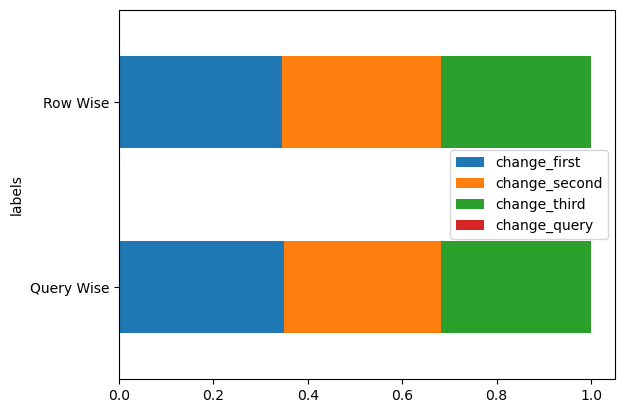

In [76]:
gp1 = group_auth_df[group_auth_df['labels'] != 'Start']
gp2 = gp1.groupby(['labels']).sum()[['change_first', 'change_second', 'change_third', 'change_profile']]
ch_sum = np.sum(gp2.values, axis = 1)

per_df = pd.DataFrame(np.divide(gp2.values, ch_sum.reshape(-1, 1)), index = gp2.index, columns = gp2.columns)
per_df.plot.barh(stacked=True)

In [77]:
list(plt_dic.keys())[4:]

['change_first', 'change_second', 'change_third', 'change_query', 'repl_auth']

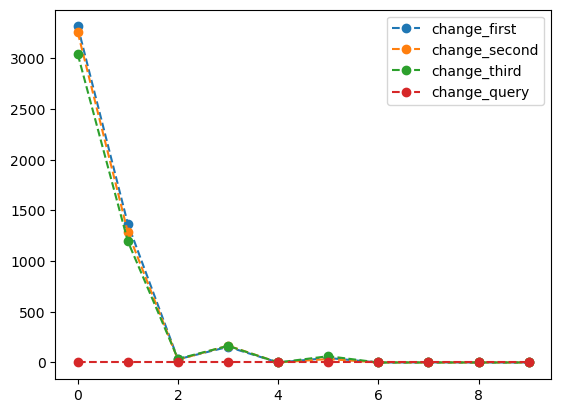

In [78]:
for key in list(plt_dic.keys())[4:8]:
    plt.plot(plt_dic[key][1:], marker = 'o', label = key, ls = 'dashed')
plt.legend()

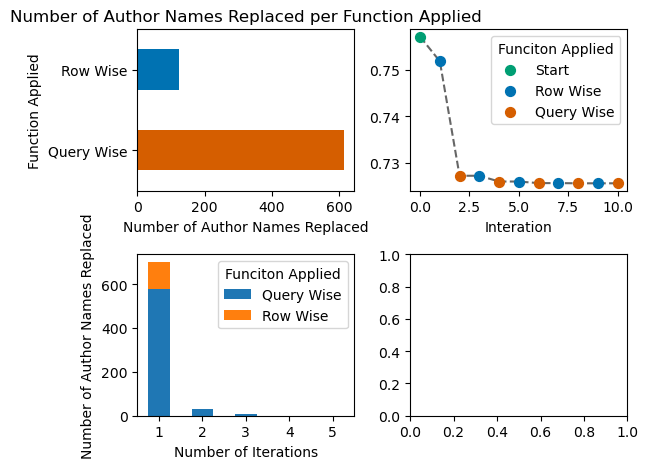

In [79]:
group_auth_df = group_auth_df[group_auth_df['labels'] != 'Start']

fig, axes = plt.subplots(2, 2)

ax = axes[0,0]
colors = group_auth_df.groupby('labels')['colors'].apply(list).str[0].values.tolist()
bar_plot = group_auth_df.groupby('labels')['repl_auth'].sum().plot(kind = 'barh', color = colors, ax = ax)

bar_plot.set_title('Number of Author Names Replaced per Function Applied')
bar_plot.set_xlabel('Number of Author Names Replaced')
bar_plot.set_ylabel('Function Applied')


ax = axes[0,1]
colors = plt_dic['colors']
num_authors = plt_dic['num_auth']
labels = plt_dic['labels']

# The average number of unique authors per citation
uni_auth_per_cit = np.divide(num_authors, join_df.shape[0])

for i in range(len(num_authors)):
    ax.scatter(i, uni_auth_per_cit[i], label = labels[i], color = colors[i], marker = 'o', s = 50)

ax.plot(uni_auth_per_cit, color = 'black', ls = 'dashed', zorder = 0, alpha = 0.6)
ax.set_xlabel('Interation')

container, label = ax.get_legend_handles_labels()
ax.legend(container[:3], label[:3], title = 'Funciton Applied', )

##############

ax = axes[1,0]
group_int_lab = group_auth_df.groupby(['iteration', 'labels']).sum().unstack()['repl_auth']
stacked_plot = group_int_lab.plot.bar(stacked=True,ax = ax)

x_ticks = np.unique(plt_dic['iteration'])
x_tick_labels = np.unique(plt_dic['iteration']) + 1
stacked_plot.set_xticks(x_ticks, x_tick_labels, rotation = 0);
stacked_plot.set_xlabel('Number of Iterations')
stacked_plot.set_ylabel('Number of Author Names Replaced')
stacked_plot.legend(title = 'Funciton Applied')


fig.tight_layout()

In [89]:
pd.DataFrame(plt_dic).to_pickle('2023-03-27_NB1_plt_df_part4.pkl')

Dropping rows with duplicated title names

In [80]:
join_df = join_df.drop_duplicates('Title')
get_unique_auth(join_df);

There are 16871 unique author names


In [81]:
papers_df = join_df.reset_index(drop = True)

In [82]:
papers_df = papers_df.drop('id', axis = 1)

In [83]:
papers_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17551 entries, 0 to 17550
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   first_auth      17551 non-null  object 
 1   second_auth     17551 non-null  object 
 2   third_auth      17551 non-null  object 
 3   Cites           17551 non-null  int16  
 4   Title           17551 non-null  object 
 5   Year            17551 non-null  int16  
 6   Source          17551 non-null  object 
 7   Type            17551 non-null  object 
 8   CitesPerYear    17551 non-null  float16
 9   CitesPerAuthor  17551 non-null  float16
 10  AuthorCount     17551 non-null  int16  
 11  query_id        17551 non-null  int16  
 12  query_author    17551 non-null  object 
dtypes: float16(2), int16(4), object(7)
memory usage: 1.1+ MB


In [86]:
papers_df.to_pickle('2023-03-27_NB1_papers_df_part4.pkl')

---